In [41]:
import polars as pl
import datetime as dt

df = (
    pl.read_csv('glbx-mdp3-20100606-20260412.ohlcv-1d.csv.zst')
    .with_columns(
        ts=pl.col('ts_event').str.to_datetime(format="%Y-%m-%dT%H:%M:%S.000000000Z"),
    )
    .select(
        ts=pl.col('ts'),
        close=pl.col('close'),
        open=pl.col("open"),
        high=pl.col("high"),
        low=pl.col("low"),
        volume=pl.col('volume'),
        symbol=pl.col('symbol').str.slice(0, pl.col('symbol').str.len_chars()-2),
        expy=pl.col('symbol').str.slice(-1).str.to_integer() + pl.col('ts').dt.year().floordiv(10) * 10,
        expm=pl.col('symbol').str.slice(-2,1),
    )
    .sort('ts', 'expy', 'expm')
    .group_by('ts')
    .agg(
        pl.col('symbol').first(),
        pl.col('open').first().cast(pl.Float32),
        pl.col('high').first().cast(pl.Float32),
        pl.col('low').first().cast(pl.Float32),
        pl.col('close').first().cast(pl.Float32),
        pl.col('volume').first(),
    )
    .select(['open','high','low','close','volume','ts','symbol'])
)

print(df)
df.write_parquet('spdr-sector-futures.parquet')

shape: (3_805, 7)
┌─────────────┬─────────────┬─────────────┬─────────────┬────────┬─────────────────────┬────────┐
│ open        ┆ high        ┆ low         ┆ close       ┆ volume ┆ ts                  ┆ symbol │
│ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---    ┆ ---                 ┆ ---    │
│ f32         ┆ f32         ┆ f32         ┆ f32         ┆ i64    ┆ datetime[μs]        ┆ str    │
╞═════════════╪═════════════╪═════════════╪═════════════╪════════╪═════════════════════╪════════╡
│ 385.700012  ┆ 385.700012  ┆ 385.0       ┆ 385.0       ┆ 2      ┆ 2011-03-28 00:00:00 ┆ XAY    │
│ 162.149994  ┆ 162.449997  ┆ 162.100006  ┆ 162.449997  ┆ 3      ┆ 2011-03-29 00:00:00 ┆ XAF    │
│ 164.449997  ┆ 164.449997  ┆ 164.449997  ┆ 164.449997  ┆ 1      ┆ 2011-03-30 00:00:00 ┆ XAF    │
│ 163.300003  ┆ 163.300003  ┆ 163.300003  ┆ 163.300003  ┆ 1      ┆ 2011-03-31 00:00:00 ┆ XAF    │
│ 164.949997  ┆ 164.949997  ┆ 163.949997  ┆ 164.0       ┆ 5      ┆ 2011-04-04 00:00:00 ┆ XAF    │
│ 

In [230]:
import itertools as it

mom_lookback = [1,3,7,14,21,30,60,90,120]
input_features = [
    # original
    "udpil",
    "udpim",
    "udpis",
    "upprob",
    "mbi",
    "tci",
    # derived
    "tcidelta",
    "mdcdelta",
    *[f"mom{n}d" for n in mom_lookback],
]

features = [
    *input_features,
    *[f"{f}roc" for f in input_features],
]

deriv_win = 7
zscore_win = 30

def rolling_zscore(expr, window):
    return (
        (expr - expr.rolling_mean(window, min_samples=1))
        / expr.rolling_std(window, min_samples=1)
    ).over("symbol")



df = (
     pl.read_parquet('polarity/data/*parquet')
    .rename(
        {
            "asset": "symbol",
            "price": "close",
            "timestamp": "ts",
        }
    )
    .with_columns(ts=pl.col("ts").dt.cast_time_unit("us"))
    .sort(["symbol", "ts"])
    # derive pct distance from *cv
    .with_columns(
        tcidelta=(pl.col("tcicv") - pl.col("close")) / pl.col("close"),
        mdcdelta=(pl.col("mdccv") - pl.col("close")) / pl.col("close"),
    )
    .with_columns(**{
        f'mom{n}d': pl.col('close') / pl.col('close').shift(n).over('symbol')
        for n in mom_lookback
    })  
    # derive 1st deriv, shift at most deriv_win, less if not enough history
    .with_columns(
        **{
            f"{col}roc": rolling_zscore(
                pl.col(col)
                - pl.coalesce(
                    [
                        pl.col(col).shift(i).over("symbol")
                        for i in range(deriv_win, 0, -1)
                    ]
                ),
                zscore_win,
            )
            for col in input_features
        }
    )
    # normalize
    .with_columns(**{col: rolling_zscore(pl.col(col), zscore_win) for col in features})
    .select(
        [
            "ts",
            "symbol",
            "close",
            *features,
        ]
    )
    .with_columns(**{
        f'fwd{n}d': pl.col('close').log().shift(-n).over('symbol') - pl.col('close').log()
        for n in [1,3,7,14,21,30]
    })
    .drop_nulls()
    .drop_nans()
    .group_by('symbol')
    .agg(**{
        f'{s}{n}d': pl.corr(pl.col(s), pl.col(f'fwd{n}d'), method='spearman')
        f'{s}{n}d': pl.corr(pl.col(s), pl.col(f'fwd{n}d'), method='spearman')
        for s,n in it.product(features, [1,3,7,14,21,30])
    })
    .mean()
    .unpivot()
    .drop_nulls()
    .with_columns(pl.col('value').cast(pl.Float32))
    .sort('value')
)

df.tail(10)

variable,spearman_ir
str,f32
"""mbi14d""",0.055365
"""udpis21d""",0.055643
"""udpis14d""",0.055793
"""mbi21d""",0.060377
"""mom30droc30d""",0.060495
"""mom30d14d""",0.066249
"""mbiroc30d""",0.068893
"""mom120d14d""",0.073213
"""mom120d21d""",0.079067


In [111]:
dtype = pl.Struct([
    pl.Field("signal", pl.String),
    pl.Field("gate", pl.String),
    pl.Field("interval_days", pl.String),
    pl.Field("max_long", pl.String),
    pl.Field("max_short", pl.String),
])

(
    pl.read_csv("results/*.csv")
    .with_columns(
        pl.col("parameters").str.json_decode(dtype)
    )
    .unnest('parameters')
    .with_columns(
        pl.col('interval_days').cast(pl.Int32),
        pl.col('max_long').cast(pl.Int32),
        pl.col('max_short').cast(pl.Int32),
    )
    .pivot(on='name', values='data')
    .select(['sortino','max_drawdown','cagr','final_equity','signal','gate','interval_days','max_long','max_short'])
    .filter(pl.col('sortino') > 1)
    .sort('sortino')
    
)

sortino,max_drawdown,cagr,final_equity,signal,gate,interval_days,max_long,max_short
f64,f64,f64,f64,str,str,i32,i32,i32
1.009535,-0.947308,0.256971,7.261075,"""mom12-1m-b""","""ema50d""",30,2,0
1.035603,-0.999818,-0.292375,0.049891,"""mom12m""","""mom12m-andor-6m""",14,1,0
1.044021,-0.999823,-0.306489,0.041896,"""mom12m""","""mom12m-andor-6m""",20,1,0
1.050548,-0.984749,-0.027154,0.787702,"""mom12-1m-a""","""mom12m-andor-6m""",3,1,0
1.073786,-0.987303,-0.013494,0.888902,"""mom12-1m-a""","""mom12m-andor-6m""",1,1,0
…,…,…,…,…,…,…,…,…
1.23023,-0.973658,0.162356,3.68462,"""mom12-1m-b""","""mom12m-andor-6m""",20,1,0
1.249025,-0.984286,0.101301,2.308135,"""mom12m""","""mom12m-andor-6m""",1,1,0
1.253257,-0.979142,0.157865,3.563021,"""mom12m""","""mom12m-andor-6m""",30,1,0


# Crypto momentum spreads (momentum-research)

In [343]:
dtype = pl.Struct([
    pl.Field("days_holding", pl.String),
    pl.Field("top_percentile", pl.String),
    pl.Field("bottom_percentile", pl.String),
    pl.Field("days_momentum", pl.String),
])

df = (
    pl.read_csv("momentum-research-backtest-results-20260422-185439/*.csv")
    .with_columns(
        pl.col("parameters").str.json_decode(dtype)
    )
    .unnest('parameters')
    .select(
        pl.col('days_holding').cast(pl.Int32),
        pl.col('top_percentile').cast(pl.Float32),
        pl.col('bottom_percentile').cast(pl.Float32),
        pl.col('days_momentum').cast(pl.Int32),
        pl.col('name'),
        pl.col('data'),
    )
    .pivot(on='name', values='data')
    .filter(pl.col('sortino') > 1)
    .sort('sortino')
)

df

days_holding,top_percentile,bottom_percentile,days_momentum,win_rate,ir,ann_std,mfe,mae,maxdd,fees,cagr,sortino,sharpe
i32,f32,f32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
30,0.5,0.1,50,0.447274,0.225903,0.592239,0.202659,-0.164122,-0.497245,0.172188,0.745716,1.000795,0.526944
14,0.9,0.25,5,0.43296,0.280543,0.650863,0.148216,-0.105684,-0.526486,0.361377,0.646826,1.000929,0.567546
7,0.95,0.25,14,0.441659,0.174015,0.627884,0.089729,-0.072025,-0.556146,0.508209,0.524106,1.002156,0.529871
60,0.99,0.25,21,0.354619,0.192674,0.65017,0.511448,-0.231762,-0.527461,0.097565,0.956169,1.005845,0.486173
60,0.9,0.25,30,0.369436,0.16585,0.61949,0.469753,-0.233996,-0.496777,0.106549,0.929115,1.005898,0.480477
…,…,…,…,…,…,…,…,…,…,…,…,…,…
7,0.99,0.05,60,0.45467,0.639458,1.578092,0.130445,-0.087621,-0.66351,1.073948,3.634884,3.403276,1.040375
14,0.99,0.05,50,0.464744,0.961166,1.615862,0.244814,-0.124376,-0.604827,0.638456,4.910474,3.49942,1.290678
30,0.99,0.05,7,0.518056,1.225145,1.323324,0.325944,-0.166343,-0.524658,0.913425,13.450588,3.559446,1.485405


Short holding periods combined with long momentum lookbacks perform the best. Short holding periods with short momentum lookbacks seem to perform worst.

In [209]:
(
    df.group_by('days_holding')
    .agg(
        ir=pl.col('ir').max()
    )
    .sort('ir')
)

days_holding,ir
i32,f64
1,0.159479
60,0.865519
7,0.880453
3,0.97603
20,0.981242
14,1.061792
30,1.40502


The maximum IR per holding period shows again short periods are better.

In [211]:
(
    df
    .filter(pl.col('sortino') > 1)
    .sort('sortino')
)

days_holding,top_percentile,bottom_percentile,days_momentum,win_rate,ir,ann_std,mfe,mae,maxdd,fees,cagr,sortino,sharpe
i32,f32,f32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
30,0.5,0.1,50,0.447274,0.225903,0.592239,0.202659,-0.164122,-0.497245,0.172188,0.745716,1.000795,0.526944
14,0.9,0.25,5,0.43296,0.280543,0.650863,0.148216,-0.105684,-0.526486,0.361377,0.646826,1.000929,0.567546
7,0.95,0.25,14,0.441659,0.174015,0.627884,0.089729,-0.072025,-0.556146,0.508209,0.524106,1.002156,0.529871
60,0.99,0.25,21,0.354619,0.192674,0.65017,0.511448,-0.231762,-0.527461,0.097565,0.956169,1.005845,0.486173
60,0.9,0.25,30,0.369436,0.16585,0.61949,0.469753,-0.233996,-0.496777,0.106549,0.929115,1.005898,0.480477
…,…,…,…,…,…,…,…,…,…,…,…,…,…
7,0.99,0.05,60,0.45467,0.639458,1.578092,0.130445,-0.087621,-0.66351,1.073948,3.634884,3.403276,1.040375
14,0.99,0.05,50,0.464744,0.961166,1.615862,0.244814,-0.124376,-0.604827,0.638456,4.910474,3.49942,1.290678
30,0.99,0.05,7,0.518056,1.225145,1.323324,0.325944,-0.166343,-0.524658,0.913425,13.450588,3.559446,1.485405


A backtest without fees supports the idea that the shortest holding periods have the best risk adjusted returns.

days_momentum,3,5,7,14,21,30,40,50,60,80,100,120,150,220
days_holding,,,,,,,,,,,,,,
60,1.276376,1.439969,1.170641,1.947596,2.446544,2.115465,2.083059,1.933607,1.400131,1.472473,1.789628,1.588940,1.622883,NaN
30,2.220562,3.016549,3.559446,2.793995,3.140643,3.141710,2.417528,4.166925,1.917564,2.186840,2.005487,1.655225,1.203973,1.159104
20,2.249340,1.734525,2.181057,2.246914,2.592265,2.443008,2.532093,2.981046,3.802196,1.366546,1.824969,NaN,1.624505,NaN
14,2.936606,3.141384,2.659369,2.915338,2.765099,2.690747,2.529994,3.499420,1.397082,1.143555,1.400996,1.470875,1.166884,NaN
7,2.419025,1.394910,1.542673,2.400554,2.951210,2.789852,1.917211,2.303657,3.403276,1.037000,1.231340,1.208057,NaN,NaN
3,1.962319,1.766564,2.913310,1.688734,1.616366,2.770216,2.363884,2.240988,3.138702,1.428223,NaN,NaN,NaN,NaN
1,NaN,NaN,1.765574,NaN,NaN,1.391283,1.143113,NaN,2.219398,NaN,NaN,NaN,NaN,NaN


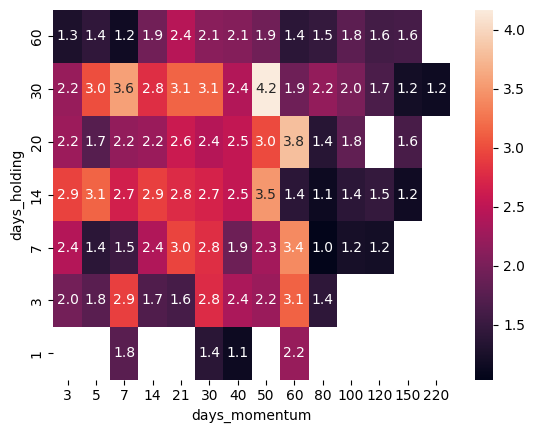

In [212]:
import seaborn as sns

hm = (
    df.sort(['days_holding','days_momentum','sortino'])
    .group_by(['days_holding','days_momentum']).last()
    .pivot(
        index="days_holding",
        on="days_momentum",
        values="sortino"
    )
)
pddf = hm.to_pandas().set_index("days_holding").sort_index(ascending=False)
pddf.columns = pddf.columns.astype(int)
pddf = pddf.sort_index(axis=1)
pddf.columns.name = "days_momentum"
sns.heatmap(
    pddf,
    annot=True,
    fmt=".1f",
)
pddf

One day holding periods outperform.

<Axes: xlabel='days_holding'>

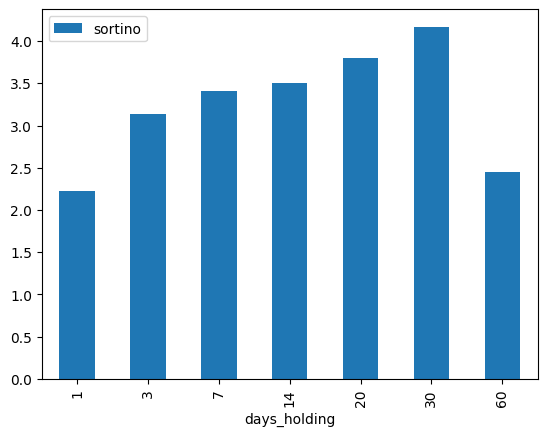

In [213]:
(
    df.sort(['days_holding','sortino'])
    .group_by('days_holding')
    .last()
    .sort('days_holding')
    .to_pandas()
    .plot(x='days_holding', y='sortino', kind='bar')
)

Sortino falls as holding periods go up.

days_holding,top_percentile,bottom_percentile,days_momentum,sharpe,fees,mae,sortino,maxdd,mfe,cagr,ir,win_rate,ann_std
i32,f32,f32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
50,0.99,0.05,40,0.416032,0.233179,-0.216536,1.021267,-0.536128,0.447612,1.719952,0.097055,0.517857,0.751538
50,0.99,0.05,60,0.493201,0.139911,-0.218674,1.030913,-0.517902,0.378788,0.939806,0.282308,0.5,0.737962
35,0.95,0.05,55,0.536587,0.258289,-0.187018,1.055496,-0.544231,0.301985,1.232941,0.286298,0.426818,0.741091
40,0.95,0.05,75,0.457898,0.222212,-0.187778,1.079471,-0.51993,0.348995,1.331356,0.191856,0.369444,0.704349
35,0.99,0.05,70,0.541296,0.235707,-0.167499,1.116449,-0.533987,0.312424,1.358804,0.337831,0.405556,0.736891
…,…,…,…,…,…,…,…,…,…,…,…,…,…
45,0.99,0.05,50,1.186445,0.178627,-0.197435,3.093911,-0.537166,0.406162,2.616802,0.872411,0.46875,1.152965
25,0.99,0.05,40,1.368389,0.639321,-0.141918,3.332685,-0.552245,0.260309,4.459329,1.088698,0.507937,1.383548
30,0.99,0.05,45,1.18196,0.265752,-0.172213,3.729552,-0.563885,0.296504,10.537457,0.863019,0.541667,1.132757


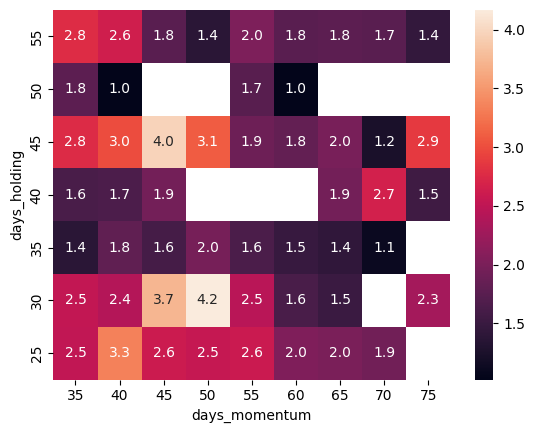

In [215]:
dtype = pl.Struct([
    pl.Field("days_holding", pl.String),
    pl.Field("top_percentile", pl.String),
    pl.Field("bottom_percentile", pl.String),
    pl.Field("days_momentum", pl.String),
])

df = (
    pl.read_csv("momentum-research-backtest-results-20260423-095445/*.csv")
    .with_columns(
        pl.col("parameters").str.json_decode(dtype)
    )
    .unnest('parameters')
    .select(
        pl.col('days_holding').cast(pl.Int32),
        pl.col('top_percentile').cast(pl.Float32),
        pl.col('bottom_percentile').cast(pl.Float32),
        pl.col('days_momentum').cast(pl.Int32),
        pl.col('name'),
        pl.col('data'),
    )
    .pivot(on='name', values='data')
    .filter(pl.col('sortino') > 1)
    .sort('sortino')
)

import seaborn as sns

hm = (
    df.sort(['days_holding','days_momentum','sortino'])
    .group_by(['days_holding','days_momentum']).last()
    .pivot(
        index="days_holding",
        on="days_momentum",
        values="sortino"
    )
)
pddf = hm.to_pandas().set_index("days_holding").sort_index(ascending=False)
pddf.columns = pddf.columns.astype(int)
pddf = pddf.sort_index(axis=1)
pddf.columns.name = "days_momentum"
sns.heatmap(
    pddf,
    annot=True,
    fmt=".1f",
)
pddf
df

days_holding,top_percentile,bottom_percentile,days_momentum,sortino,cagr,ir,ann_std,sharpe,win_rate,mfe,mae,maxdd,fees
i32,f32,f32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
35,0.95,0.05,47,1.051155,1.52881,0.176541,0.719429,0.480308,0.42803,0.302321,-0.188341,-0.559342,0.261723
35,0.95,0.05,55,1.055496,1.232941,0.286298,0.741091,0.536587,0.426818,0.301985,-0.187018,-0.544231,0.258289
28,0.99,0.05,55,1.081699,0.743537,0.243766,0.865851,0.541406,0.433761,0.263003,-0.169308,-0.569542,0.197183
35,0.95,0.05,46,1.103012,1.556082,0.192381,0.715024,0.502694,0.43803,0.306306,-0.187818,-0.587916,0.257285
34,0.95,0.05,52,1.104025,1.118658,0.30304,0.753548,0.554171,0.486818,0.275214,-0.19508,-0.516265,0.217205
…,…,…,…,…,…,…,…,…,…,…,…,…,…
27,0.99,0.05,51,3.831884,3.39935,1.090978,1.299926,1.372112,0.429487,0.299089,-0.159087,-0.540608,0.626569
31,0.99,0.05,50,3.940001,4.364265,1.253539,1.283986,1.469064,0.448864,0.368633,-0.172359,-0.637177,0.813974
26,0.99,0.05,46,4.008239,5.661483,1.313346,1.175604,1.525064,0.507937,0.311724,-0.167748,-0.527964,1.215482


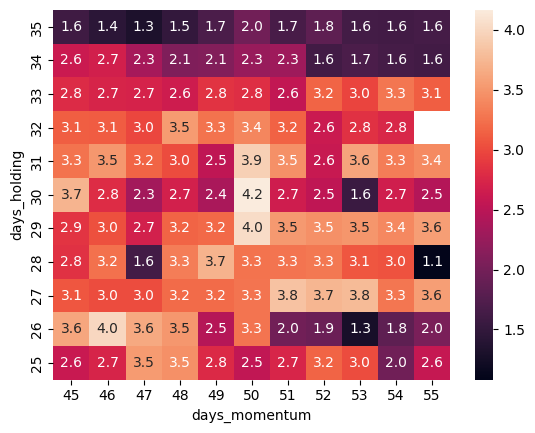

In [216]:
dtype = pl.Struct([
    pl.Field("days_holding", pl.String),
    pl.Field("top_percentile", pl.String),
    pl.Field("bottom_percentile", pl.String),
    pl.Field("days_momentum", pl.String),
])

df = (
    pl.read_csv("momentum-research-backtest-results-20260423-101049/*.csv")
    .with_columns(
        pl.col("parameters").str.json_decode(dtype)
    )
    .unnest('parameters')
    .select(
        pl.col('days_holding').cast(pl.Int32),
        pl.col('top_percentile').cast(pl.Float32),
        pl.col('bottom_percentile').cast(pl.Float32),
        pl.col('days_momentum').cast(pl.Int32),
        pl.col('name'),
        pl.col('data'),
    )
    .pivot(on='name', values='data')
    .filter(pl.col('sortino') > 1)
    .sort('sortino')
)

import seaborn as sns

hm = (
    df.sort(['days_holding','days_momentum','sortino'])
    .group_by(['days_holding','days_momentum']).last()
    .pivot(
        index="days_holding",
        on="days_momentum",
        values="sortino"
    )
)
pddf = hm.to_pandas().set_index("days_holding").sort_index(ascending=False)
pddf.columns = pddf.columns.astype(int)
pddf = pddf.sort_index(axis=1)
pddf.columns.name = "days_momentum"
sns.heatmap(
    pddf,
    annot=True,
    fmt=".1f",
)
pddf
df

days_holding,top_percentile,bottom_percentile,days_momentum,ann_std,win_rate,mae,ir,sharpe,mfe,sortino,cagr,maxdd,fees
i32,f32,f32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
14,0.75,null,100,0.607337,0.456481,-0.096628,0.174821,0.425129,0.135304,1.007764,1.368008,-0.476291,0.633224
30,0.75,null,80,0.590037,0.445609,-0.164715,0.185233,0.433139,0.221545,1.0187,1.333074,-0.469381,0.290327
7,0.9,null,40,0.696191,0.431282,-0.081018,0.093967,0.364786,0.098426,1.018871,2.18372,-0.555114,2.322649
20,0.99,null,220,1.025479,0.419444,-0.151991,0.406507,0.436084,0.239997,1.046188,1.064479,-0.65269,0.186372
3,0.95,null,14,0.855751,0.46093,-0.055919,-0.259359,-0.031404,0.061581,1.046523,7.149808,-0.656494,27.710942
…,…,…,…,…,…,…,…,…,…,…,…,…,…
20,0.99,null,50,1.89659,0.516667,-0.1376,0.84045,1.043255,0.281764,2.754346,8.332772,-0.699501,1.318138
14,0.99,null,30,2.345294,0.42033,-0.161954,0.867515,1.080189,0.2126,2.765751,6.410431,-0.774872,3.606686
7,0.99,null,30,2.494974,0.417582,-0.138245,0.925749,1.123953,0.117256,2.768243,6.228715,-0.81105,5.724928


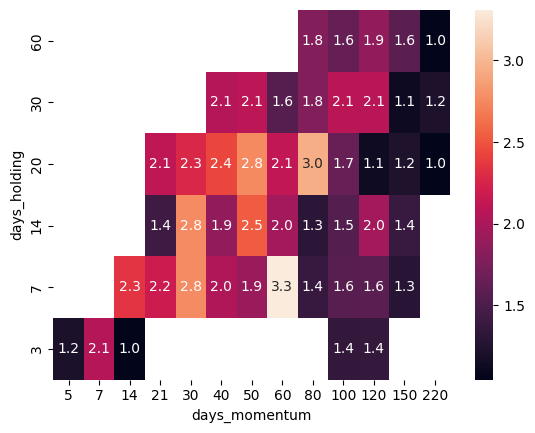

In [227]:
dtype = pl.Struct([
    pl.Field("days_holding", pl.String),
    pl.Field("top_percentile", pl.String),
    pl.Field("bottom_percentile", pl.String),
    pl.Field("days_momentum", pl.String),
])

df = (
    pl.read_csv("momentum-research-backtest-results-20260423-104824/*.csv")
    .with_columns(
        pl.col("parameters").str.json_decode(dtype)
    )
    .unnest('parameters')
    .select(
        pl.col('days_holding').cast(pl.Int32),
        pl.col('top_percentile').cast(pl.Float32),
        (
            pl.when(pl.col('bottom_percentile') == 'None')
            .then(pl.lit(None).alias('bottom_percentile'))
            .otherwise(pl.col('bottom_percentile'))
            .cast(pl.Float32)
        ),
        pl.col('days_momentum').cast(pl.Int32),
        pl.col('name'),
        pl.col('data'),
    )
    .pivot(on='name', values='data')
    .filter((pl.col('sortino') > 1) & (pl.col('days_holding') < pl.col('days_momentum')))
    .sort('sortino')
)

import seaborn as sns

hm = (
    df.sort(['days_holding','days_momentum','sortino'])
    .group_by(['days_holding','days_momentum']).last()
    .pivot(
        index="days_holding",
        on="days_momentum",
        values="sortino"
    )
)
pddf = hm.to_pandas().set_index("days_holding").sort_index(ascending=False)
pddf.columns = pddf.columns.astype(int)
pddf = pddf.sort_index(axis=1)
pddf.columns.name = "days_momentum"
sns.heatmap(
    pddf,
    annot=True,
    fmt=".1f",
)
pddf
df

**Todo**

- [x] add fees
- [ ] experiment with stops
- [ ] check for lookahead bias
- [ ] spread analysis for pd metrics
- [ ] volume weight portfolio
- [x] explore more around 30d holding period and 50d momentum
- [ ] above mdc as gate
- [ ] eval mean reversion vs trend following

In [232]:
pl.read_parquet('yf.parquet')

open,high,low,close,volume,ts,symbol
f32,f32,f32,f32,i64,datetime[μs],str
24.192579,24.192579,24.072218,24.175385,1003200,1993-01-29 00:00:00,"""SPY"""
24.192579,24.34733,24.192579,24.34733,480500,1993-02-01 00:00:00,"""SPY"""
24.330126,24.416098,24.278542,24.398903,201300,1993-02-02 00:00:00,"""SPY"""
24.433298,24.674021,24.416103,24.656826,529400,1993-02-03 00:00:00,"""SPY"""
24.742802,24.811581,24.467691,24.759996,531500,1993-02-04 00:00:00,"""SPY"""
…,…,…,…,…,…,…
114.650002,116.830002,114.580002,116.440002,8128600,2026-04-14 00:00:00,"""XLY"""
116.529999,118.440002,116.150002,118.18,8034700,2026-04-15 00:00:00,"""XLY"""
118.400002,118.550003,117.099998,117.629997,5671900,2026-04-16 00:00:00,"""XLY"""


In [242]:
dtype = pl.Struct([
    pl.Field("days_holding", pl.String),
    pl.Field("n_buckets", pl.String),
    pl.Field("days_momentum", pl.String),
    pl.Field("ema_slow", pl.String),
    pl.Field("volume_cutoff", pl.String),
])

(
    pl.read_csv("cs-momentum-trail-resilts-1/*.csv")
    .with_columns(
        pl.col("parameters").str.json_decode(dtype)
    )
    .unnest('parameters')
    .with_columns(
        pl.col('days_holding').cast(pl.Int32),
        pl.col('n_buckets').cast(pl.Int32),
        pl.col('days_momentum').cast(pl.Int32),
        pl.col('ema_slow').cast(pl.Int32),
    )
    .pivot(on='name', values='data')
    .select(['sortino','max_drawdown','cagr','final_equity','days_holding','n_buckets','ema_slow','days_momentum','volume_cutoff'])
    .filter(pl.col('sortino') > 1)
    .sort('sortino')
    
).write_csv('cs-momentum-results-1.csv')

In [249]:
dtype = pl.Struct([
    pl.Field("days_holding", pl.String),
    pl.Field("n_buckets", pl.String),
    pl.Field("days_momentum", pl.String),
    pl.Field("ema_slow", pl.String),
    pl.Field("volume_cutoff", pl.String),
])

(
    pl.read_csv("cs-momentum-results-2/results/*.csv")
    .with_columns(
        pl.col("parameters").str.json_decode(dtype)
    )
    .unnest('parameters')
    .with_columns(
        pl.col('days_holding').cast(pl.Int32),
        pl.col('n_buckets').cast(pl.Int32),
        pl.col('days_momentum').cast(pl.Int32),
        pl.col('ema_slow').cast(pl.Int32),
    )
    .pivot(on='name', values='data')
    #.filter(pl.col('sortino') > 1)
    .sort('ir')
    
)

notebook,ts,days_holding,n_buckets,days_momentum,ema_slow,volume_cutoff,sortino,cagr,mfe,win_rate,mae,maxdd,ann_return,mfe_std,mae_std,ann_std,ir,fees,sharpe
str,str,i32,i32,i32,i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""cs-crypto-momentum.ipynb""","""2026-04-27T07:09:54.068625""",1,10,40,50,"""10_000_000""",-1.813767,-0.600742,0.224143,0.427686,-0.117716,-0.688494,-0.524526,0.252171,0.096568,0.550404,-1.493018,0.069955,-1.565309
"""cs-crypto-momentum.ipynb""","""2026-04-27T07:10:21.962266""",1,10,50,50,"""10_000_000""",-1.78513,-0.557736,0.232942,0.441258,-0.12331,-0.683818,-0.501692,0.255569,0.103433,0.544219,-1.465593,0.07427,-1.585508
"""cs-crypto-momentum.ipynb""","""2026-04-27T10:31:16.424968""",7,10,50,60,"""10_000_000""",-1.529389,-0.601938,0.238584,0.315043,-0.178459,-0.650618,-0.496783,0.28749,0.119723,0.520293,-1.413018,0.017534,-1.142543
"""cs-crypto-momentum.ipynb""","""2026-04-27T10:31:12.710801""",7,10,40,80,"""10_000_000""",-1.529638,-0.567948,0.223816,0.319829,-0.160111,-0.638923,-0.508692,0.256288,0.127728,0.507715,-1.41209,0.018202,-1.151311
"""cs-crypto-momentum.ipynb""","""2026-04-27T10:31:19.015643""",7,10,50,80,"""10_000_000""",-1.499844,-0.573041,0.235154,0.323569,-0.174854,-0.63726,-0.494198,0.281976,0.122014,0.509244,-1.403237,0.017486,-1.117117
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""cs-crypto-momentum.ipynb""","""2026-04-27T05:46:46.237017""",1,4,14,120,"""100_000_000""",0.91737,0.177512,0.123577,0.594465,-0.056566,-0.326475,0.210832,0.18923,0.059939,0.410571,-0.129156,0.277099,0.505604
"""cs-crypto-momentum.ipynb""","""2026-04-27T07:36:18.494773""",3,4,14,100,"""100_000_000""",1.048516,0.243877,0.160974,0.571897,-0.071819,-0.317466,0.223778,0.22987,0.066804,0.403131,-0.090443,0.166595,0.571179
"""cs-crypto-momentum.ipynb""","""2026-04-27T07:36:32.889947""",3,4,14,120,"""100_000_000""",1.09762,0.259587,0.158641,0.56713,-0.071457,-0.317683,0.233558,0.229643,0.066212,0.404477,-0.067073,0.170546,0.599318


In [4]:
import polars as pl
from dotenv import load_dotenv
import os

load_dotenv()

so = {
    "aws_access_key_id": os.getenv("R2_ACCESS_KEY"),
    "aws_secret_access_key": os.getenv("R2_SECRET_KEY"),
    "aws_endpoint_url": f"https://{os.getenv('R2_ACCOUNT_ID')}.r2.cloudflarestorage.com",
    "aws_region": "auto",  # R2 requires 'auto' or 'us-east-1' (aliased to auto)
}


frag = []
for yr in range(2023,2027):
    u = f"s3://studies-binance-store/spot-1m/year={yr}/"
    frag.append(pl.scan_parquet(u, storage_options=so, hive_partitioning=True))

(
    pl.concat(frag)
    .filter(pl.col('symbol').str.ends_with('USDC'))
    .sink_parquet('stables-1m.parquet')
)

In [ ]:
import polars as pl
    
(
    pl.scan_parquet('stables-1m.parquet')
    .sort(['symbol','ts'])
    .with_columns(
        vol=(pl.col('quote_volume') - pl.col('quote_volume').rolling_mean(24*60).over('symbol')) / pl.col('quote_volume').rolling_std(24*60).over('symbol'),
        fwd15=pl.col('close').pct_change(-1).over('symbol'),
        fwd15=pl.col('close').pct_change(-15).over('symbol'),
        fwd30=pl.col('close').pct_change(-30).over('symbol'),
        fwd45=pl.col('close').pct_change(-45).over('symbol'),
        fwd60=pl.col('close').pct_change(-60).over('symbol'),
        fwd90=pl.col('close').pct_change(-90).over('symbol'),
        fwd120=pl.col('close').pct_change(-120).over('symbol'),
        fwd240=pl.col('close').pct_change(-240).over('symbol'),
        fwd360=pl.col('close').pct_change(-360).over('symbol'),
        fwd480=pl.col('close').pct_change(-480).over('symbol'),
        fwd600=pl.col('close').pct_change(-600).over('symbol'),
        fwd1200=pl.col('close').pct_change(-1200).over('symbol'),
        fwd2400=pl.col('close').pct_change(-2400).over('symbol'),
        fwd3600=pl.col('close').pct_change(-3600).over('symbol'),
        fwd4800=pl.col('close').pct_change(-4800).over('symbol'),
        fwd6000=pl.col('close').pct_change(-6000).over('symbol'),
        mom=pl.col('close').pct_change(15).over('symbol')
    )
    .filter((pl.col('mom') >= 0.2) & (pl.col('vol') > 2))
).sink_csv('stats.csv')

shape: (64, 5)
┌──────┬──────────┬──────────┬──────────┬─────────┐
│ ts   ┆ variable ┆ mean     ┆ std      ┆ minutes │
│ ---  ┆ ---      ┆ ---      ┆ ---      ┆ ---     │
│ i32  ┆ str      ┆ f64      ┆ f64      ┆ i32     │
╞══════╪══════════╪══════════╪══════════╪═════════╡
│ 2025 ┆ fwd1     ┆ 0.000942 ┆ 0.059091 ┆ 1       │
│ 2023 ┆ fwd1     ┆ 0.179266 ┆ 0.346449 ┆ 1       │
│ 2026 ┆ fwd1     ┆ 0.00513  ┆ 0.053635 ┆ 1       │
│ 2024 ┆ fwd1     ┆ 0.130561 ┆ 0.287296 ┆ 1       │
│ 2025 ┆ fwd15    ┆ 0.043044 ┆ 0.423348 ┆ 15      │
│ …    ┆ …        ┆ …        ┆ …        ┆ …       │
│ 2024 ┆ fwd4800  ┆ 0.132333 ┆ 0.319005 ┆ 4800    │
│ 2025 ┆ fwd6000  ┆ 0.157895 ┆ 0.606242 ┆ 6000    │
│ 2023 ┆ fwd6000  ┆ 0.345409 ┆ 0.308963 ┆ 6000    │
│ 2026 ┆ fwd6000  ┆ 0.583783 ┆ 1.305327 ┆ 6000    │
│ 2024 ┆ fwd6000  ┆ 0.147595 ┆ 0.331295 ┆ 6000    │
└──────┴──────────┴──────────┴──────────┴─────────┘


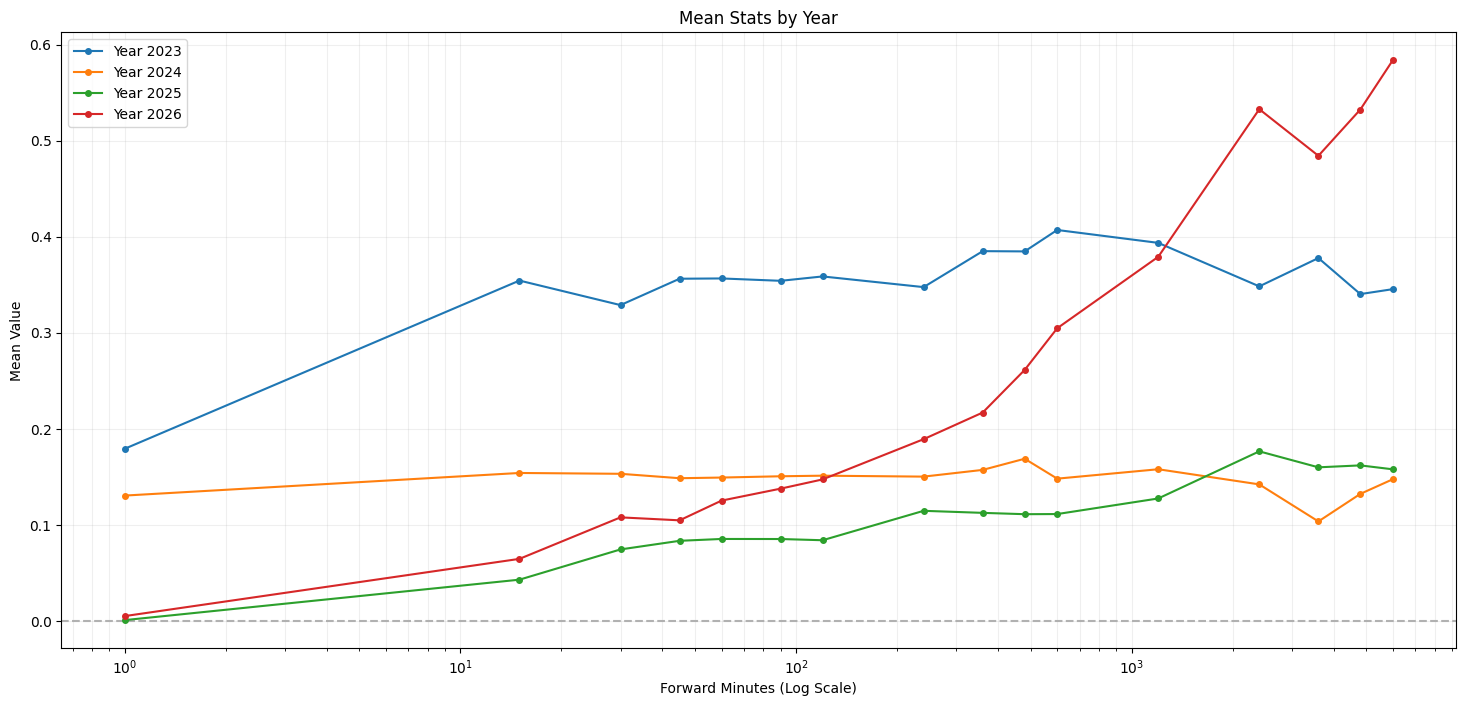

In [30]:
import polars as pl
import matplotlib.pyplot as plt

mins = [1,15,30,45,60,90,120,240,360,480,600,1200,2400,3600,4800,6000]
df = pl.read_csv('stats.csv', try_parse_dates=True).group_by(pl.col('ts').dt.year())
avg = df.agg([pl.col(f'fwd{n}').mean() for n in mins]).unpivot(index="ts", on=[f"fwd{n}" for n in mins])
std = df.agg([pl.col(f'fwd{n}').std() for n in mins]).unpivot(index="ts", on=[f"fwd{n}" for n in mins])

df = (
    avg
    .rename({'value':'mean'})
    .join(
        std.rename({'value':'std'}),
        on=['ts','variable']
    )
    .with_columns(
        minutes=pl.col('variable').str.extract(r"(\d+)", 1).cast(pl.Int32)
    )
)
print(df)

plt.figure(figsize=(18, 8))

for year in df['ts'].unique().to_list():
    # Filter data for the specific year
    year_data = df.filter(pl.col("ts") == year)
    
    plt.plot(
        year_data["minutes"], 
        year_data["mean"], 
        marker='o', 
        markersize=4,
        label=f"Year {year}"
    )
plt.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)
# 3. Formatting
plt.xscale('log')  # Log scale makes 15 vs 6000 readable
plt.xlabel("Forward Minutes (Log Scale)")
plt.ylabel("Mean Value")
plt.title("Mean Stats by Year")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

In [96]:
pl.read_parquet('stables-1d.parquet')
df = (
    pl.read_parquet('polarity/data/*.parquet')
    .rename({'asset': 'symbol'})
    .sort(['symbol','ts'])
    .with_columns(
        fwd=pl.col('price').pct_change(-30).over('symbol'),
        mom=pl.col('price').pct_change(30*3).over('symbol'),
    )
    .filter(pl.col('mom').is_not_null() & pl.col('fwd').is_not_null())
    .with_columns(
        rank=pl.col('mom').qcut(
            10,
            labels=[str(i) for i in range(10)],
            allow_duplicates=True
        ).over('ts'),
    )
    .filter((pl.col('rank') == '9') & (pl.col('mom') > 0) & (pl.col('ts').dt.year() >= 2023))
    .select(['ts','symbol','rank','mom','fwd'])
    .group_by('ts')
    .agg(
        pl.col('fwd').mean()
    )
)

print(df.mean(), df.std())

shape: (1, 2)
┌─────────────────────┬──────────┐
│ ts                  ┆ fwd      │
│ ---                 ┆ ---      │
│ datetime[μs]        ┆ f64      │
╞═════════════════════╪══════════╡
│ 2024-09-02 00:00:00 ┆ 0.062304 │
└─────────────────────┴──────────┘ shape: (1, 2)
┌──────────────┬──────────┐
│ ts           ┆ fwd      │
│ ---          ┆ ---      │
│ datetime[μs] ┆ f64      │
╞══════════════╪══════════╡
│ null         ┆ 0.194978 │
└──────────────┴──────────┘


Cleaned Mean: 0.0579, Cleaned Std Dev: 0.1729


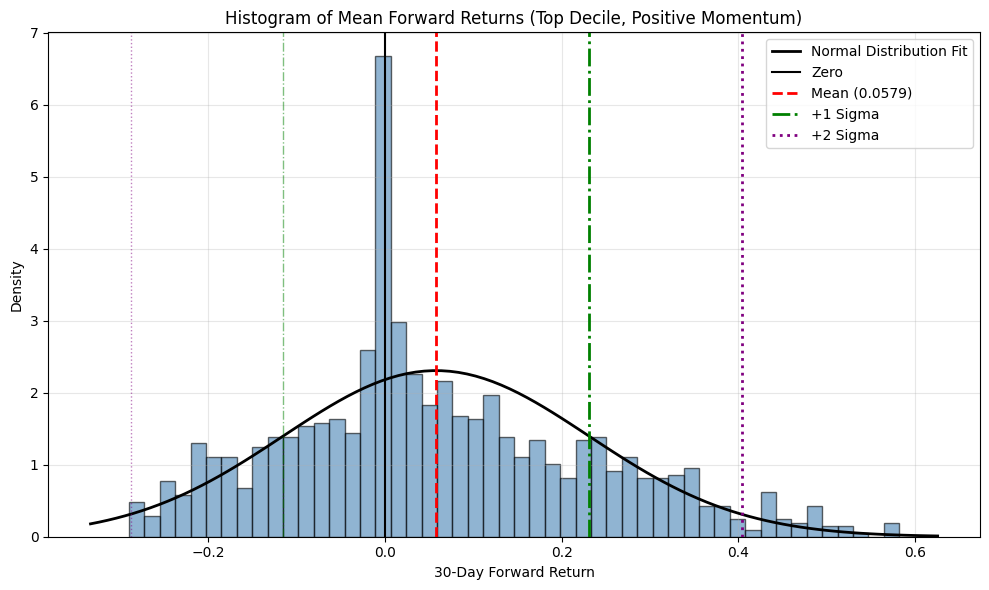

In [97]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# 1. Your original backtest logic
df = (
    pl.scan_parquet('polarity/data/*.parquet')  # Using scan for better memory management
    .rename({'asset': 'symbol'})
    .sort(['symbol','ts'])
    .with_columns(
        fwd=pl.col('price').pct_change(-30).over('symbol'),
        mom=pl.col('price').pct_change(30*3).over('symbol'),
    )
    .filter(pl.col('mom').is_not_null() & pl.col('fwd').is_not_null())
    .with_columns(
        rank=pl.col('mom').qcut(
            10,
            labels=[str(i) for i in range(10)],
            allow_duplicates=True
        ).over('ts'),
    )
    .filter((pl.col('rank') == '9') & (pl.col('mom') > 0) & (pl.col('ts').dt.year() >= 2023))
    .select(['ts','symbol','rank','mom','fwd'])
    .group_by('ts')
    .agg(
        pl.col('fwd').mean()
    )
    .collect() # Execute the query
)

# ... [Keep Step 1 exactly the same to get your df] ...

# 2. Extract returns
returns = df.drop_nulls('fwd')['fwd'].to_numpy()

# NEW: Filter out extreme outliers using percentiles
# This removes the craziest 1% of spikes and drops
lower_bound = np.percentile(returns, 1)
upper_bound = np.percentile(returns, 99)
clean_returns = returns[(returns >= lower_bound) & (returns <= upper_bound)]

# Calculate moments on the CLEANED data
mu = np.mean(clean_returns)
sigma = np.std(clean_returns)

print(f"Cleaned Mean: {mu:.4f}, Cleaned Std Dev: {sigma:.4f}")

# 3. Build the Plot (using clean_returns)
plt.figure(figsize=(10, 6))

# Histogram using the cleaned data
plt.hist(clean_returns, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='black')

# Generate x-values for the bell curve based on the new, sane limits
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Calculate and plot the PDF
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, 'k', linewidth=2, label='Normal Distribution Fit')

# 4. Mark the specific lines
plt.axvline(0, color='black', linestyle='-', linewidth=1.5, label='Zero')
plt.axvline(mu, color='red', linestyle='--', linewidth=2, label=f'Mean ({mu:.4f})')

# Plus 1 and 2 Sigma
plt.axvline(mu + sigma, color='green', linestyle='-.', linewidth=2, label='+1 Sigma')
plt.axvline(mu + 2*sigma, color='purple', linestyle=':', linewidth=2, label='+2 Sigma')

# (Optional but recommended) Minus 1 and 2 Sigma for visual symmetry
plt.axvline(mu - sigma, color='green', linestyle='-.', linewidth=1, alpha=0.5)
plt.axvline(mu - 2*sigma, color='purple', linestyle=':', linewidth=1, alpha=0.5)

# 5. Formatting
plt.title('Histogram of Mean Forward Returns (Top Decile, Positive Momentum)')
plt.xlabel('30-Day Forward Return')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()

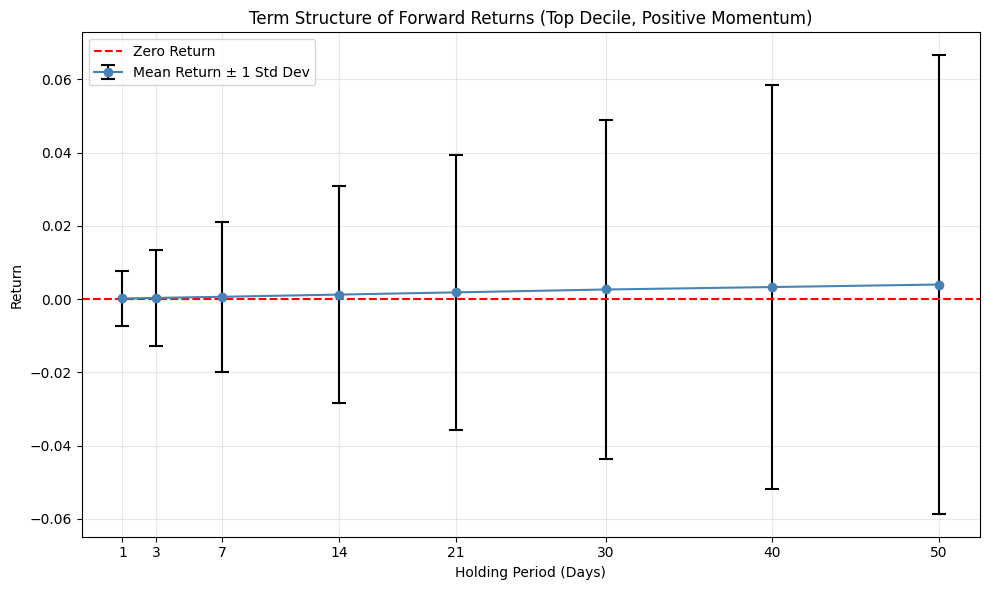

In [94]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the holding periods we want to look forward
horizons = [1, 3, 7, 14, 21, 30, 40, 50]

# Generate a list of Polars expressions for each horizon
fwd_exprs = [
    pl.col('price').pct_change(-h).over('symbol').alias(f'fwd_{h}d') 
    for h in horizons
]

# 2. Polars Data Pipeline
df = (
    pl.scan_parquet('polarity/data/*.parquet')
    .rename({'asset': 'symbol'})
    .sort(['symbol','ts'])
    .with_columns(
        mom = pl.col('price').pct_change(90).over('symbol'), # 90-day momentum
        *fwd_exprs # Unpack the list of forward return expressions
    )
    .filter(pl.col('mom').is_not_null())
    .with_columns(
        rank=pl.col('mom').qcut(
            10,
            labels=[str(i) for i in range(10)],
            allow_duplicates=True
        ).over('ts'),
    )
    .filter((pl.col('rank') == '9') & (pl.col('mom') > 0))
    # Select only the columns we need for plotting to save memory
    .select([f'fwd_{h}d' for h in horizons]) 
    .collect()
)

# 3. Calculate Cleaned Means and Standard Deviations
means = []
stds = []

for h in horizons:
    col_name = f'fwd_{h}d'
    
    # Drop nulls for this specific horizon (e.g., the last 50 days of the dataset)
    returns = df.drop_nulls(col_name)[col_name].to_numpy()
    
    # Apply the outlier filter (1st and 99th percentiles) to clean the data
    if len(returns) > 0:
        lower_bound = np.percentile(returns, 1)
        upper_bound = np.percentile(returns, 99)
        clean_returns = returns[(returns >= lower_bound) & (returns <= upper_bound)]
        
        means.append(np.mean(clean_returns))
        
        # NOTE: We are plotting Standard Deviation. If you want Standard Error of the Mean (SEM) 
        # to show confidence intervals instead, use: np.std(clean_returns) / np.sqrt(len(clean_returns))
        stds.append(np.std(clean_returns)) 
    else:
        means.append(0)
        stds.append(0)

# 4. Build the Error Bar Plot
plt.figure(figsize=(10, 6))

# plt.errorbar handles both the line plot and the vertical bars
plt.errorbar(
    x=horizons, 
    y=means, 
    yerr=stds, 
    fmt='-o',           # Line with circle markers
    color='steelblue', 
    ecolor='black',     # Color of the error bars
    capsize=5,          # Width of the caps on the error bars
    capthick=1.5,
    markersize=6,
    label='Mean Return ± 1 Std Dev'
)

# Add a reference line at zero
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Return')

# Formatting
plt.title('Term Structure of Forward Returns (Top Decile, Positive Momentum)')
plt.xlabel('Holding Period (Days)')
plt.ylabel('Return')
plt.xticks(horizons) # Force x-axis to show our specific horizons
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Display the plot
plt.show()

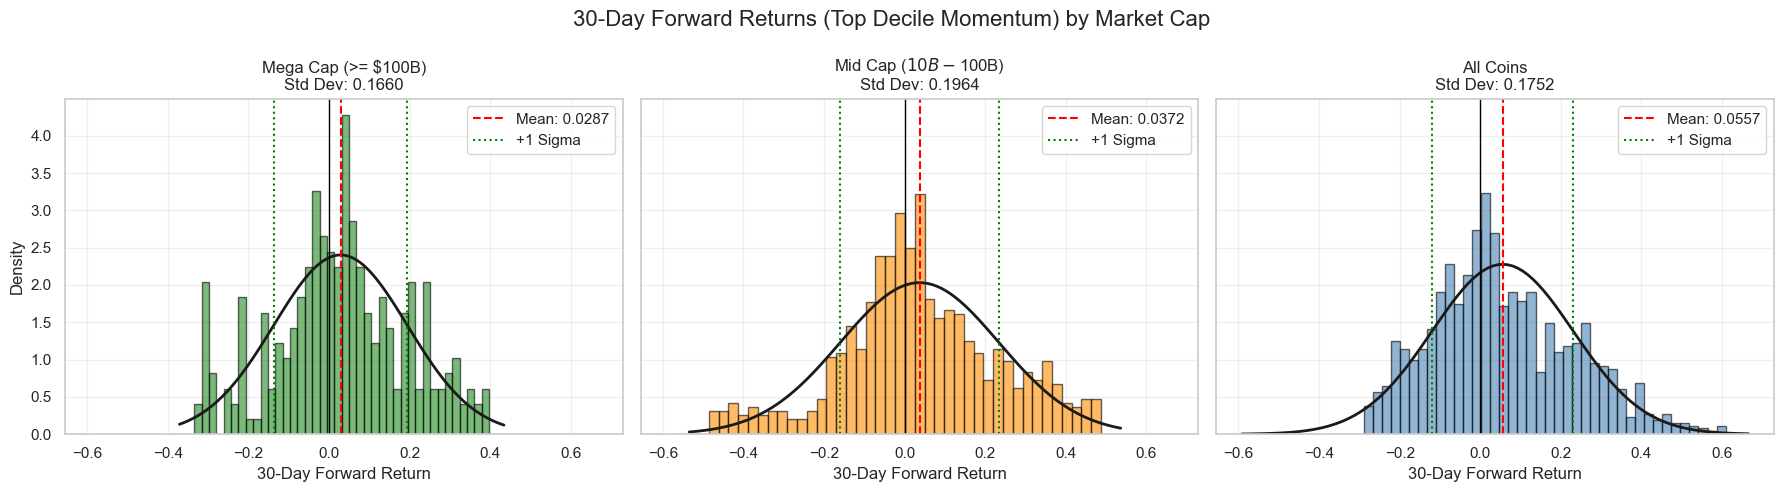

In [331]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# 1. Base Data Pipeline
# Assuming 'mcap' is available in your raw data
df_base = (
    pl.scan_parquet('polarity/latest-data/*.parquet')
    .rename({'asset': 'symbol'})
    .sort(['symbol','ts'])
    .with_columns(
        fwd=pl.col('price').pct_change(-30).over('symbol'),
        mom=pl.col('price').pct_change(90).over('symbol'), # 90-day momentum
    )
    .filter(pl.col('mom').is_not_null() & pl.col('fwd').is_not_null())
    .with_columns(
        rank=pl.col('mom').qcut(
            10,
            labels=[str(i) for i in range(10)],
            allow_duplicates=True
        ).over('ts'),
    )
    .filter((pl.col('rank') == '9') & (pl.col('mom') > 0) & (pl.col('ts').dt.year() >= 2023))
    # We must explicitly select 'mcap' so it is available for filtering below
    .select(['ts', 'symbol', 'market_cap', 'fwd']) 
    .collect()
)

# 2. Define Market Cap Buckets (Assuming mcap is in raw dollars)
# If your data stores mcap in millions, adjust these thresholds (e.g., 10000 instead of 10_000_000_000)
buckets = {
    "Mega Cap (>= $10B)": df_base.filter(pl.col('market_cap') >= 10_000_000_000),
    "Mid Cap ($1B - $10B)": df_base.filter((pl.col('market_cap') >= 1_000_000_000) & (pl.col('market_cap') < 10_000_000_000)),
    "All Coins": df_base
}

# 3. Setup the Subplots
# sharex=True and sharey=True are critical so the visual scale matches across all 3 charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
fig.suptitle('30-Day Forward Returns (Top Decile Momentum) by Market Cap', fontsize=16)

colors = ['forestgreen', 'darkorange', 'steelblue']

# 4. Process and Plot Each Bucket
for ax, (title, subset_df), color in zip(axes, buckets.items(), colors):
    
    # Calculate daily mean returns for this specific mcap bucket
    daily_returns_df = (
        subset_df.group_by('ts')
        .agg(pl.col('fwd').mean())
        .drop_nulls('fwd')
    )
    
    returns = daily_returns_df['fwd'].to_numpy()
    
    # Outlier handling (1st and 99th percentile) to ensure clean bell curves
    if len(returns) > 0:
        lower_bound = np.percentile(returns, 1)
        upper_bound = np.percentile(returns, 99)
        clean_returns = returns[(returns >= lower_bound) & (returns <= upper_bound)]
        
        mu = np.mean(clean_returns)
        sigma = np.std(clean_returns)
        
        # Histogram
        ax.hist(clean_returns, bins=40, density=True, alpha=0.6, color=color, edgecolor='black')
        
        # Bell Curve
        xmin, xmax = ax.get_xlim() # Get axis limits to draw the line
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mu, sigma)
        ax.plot(x, p, 'k', linewidth=2)
        
        # Markings
        ax.axvline(0, color='black', linestyle='-', linewidth=1)
        ax.axvline(mu, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mu:.4f}')
        ax.axvline(mu + sigma, color='green', linestyle=':', linewidth=1.5, label='+1 Sigma')
        ax.axvline(mu - sigma, color='green', linestyle=':', linewidth=1.5)
        
        ax.set_title(f'{title}\nStd Dev: {sigma:.4f}')
        ax.legend()
    else:
        ax.set_title(f'{title}\n(Not Enough Data)')
    
    ax.set_xlabel('30-Day Forward Return')
    ax.grid(True, alpha=0.3)

# Formatting the Y-axis only on the first chart to reduce clutter
axes[0].set_ylabel('Density')
plt.tight_layout()
plt.show()

In [108]:
parameters = [
    "holding_days",
    "long_decile",
    "short_decile",
    "momentum_days",
    "min_mcap",
]

dtype = pl.Struct([pl.Field(p, pl.String) for p in parameters])

df = (
    pl.read_csv("pd-momentum-results-20260505-152721/*.csv")
    .with_columns(
        pl.col("parameters").str.json_decode(dtype)
    )
    .unnest('parameters')
    .select([
        *[pl.col(p).cast(pl.Float32) for p in parameters],
        pl.col('name'),
        pl.col('data'),
    ])
    .pivot(on='name', values='data')
    .filter(pl.col('sortino') > 1)
    .sort('sortino')
)

df

holding_days,long_decile,short_decile,momentum_days,min_mcap,fees,sharpe,mae,win_rate,sortino,mae_std,ir,cagr,mfe_std,mfe,ann_return,maxdd,ann_std
f32,f32,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
30.0,8.0,-1.0,7.0,1e6,1.150172,0.936847,-0.148286,0.518674,1.879814,0.149373,0.24118,2.612702,1.499159,0.496336,0.643129,-0.489343,0.584328
30.0,9.0,-1.0,7.0,1e6,1.865232,1.057586,-0.152724,0.507133,2.226226,0.148787,0.498892,2.739969,2.915056,0.831428,0.925559,-0.502902,0.75449
7.0,8.0,-1.0,7.0,1e6,9.882208,1.101292,-0.067364,0.538963,2.343822,0.0833,0.529021,3.728923,2.233055,0.344143,0.960014,-0.556172,0.739509
30.0,8.0,-1.0,30.0,1e6,1.38131,1.221336,-0.135984,0.545648,2.364727,0.144579,0.560498,2.127898,3.060723,0.855232,0.7325,-0.477264,0.580882
1.0,8.0,-1.0,14.0,1e6,10.963862,0.87084,-0.053634,0.637841,2.467258,0.089271,0.289996,3.470708,0.709359,0.194914,0.69785,-0.568812,0.635145
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3.0,9.0,-1.0,7.0,1e6,224.100204,1.43147,-0.052761,0.583785,3.658425,0.072328,1.004684,7.006161,1.308336,0.26153,1.378863,-0.549451,0.881709
14.0,9.0,-1.0,14.0,1e6,141.61725,1.781748,-0.103691,0.559839,3.788228,0.11358,1.22141,7.900599,2.093001,0.576722,2.146032,-0.525768,1.150618
14.0,9.0,-1.0,7.0,1e6,129.714184,1.70257,-0.109338,0.53539,3.812548,0.113903,1.168335,8.560495,1.833741,0.469013,2.156246,-0.561084,1.157359


In [2]:
import polars as pl

pl.read_csv('cmc_historical_data_2020.csv')

id,slug,name,symbol,timestamp,ref_cur_id,ref_cur_name,time_open,time_close,time_high,time_low,open,high,low,close,volume,market_cap,circulating_supply
i64,str,str,str,str,i64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,i64
1,"""bitcoin""","""Bitcoin""","""BTC""","""2020-01-01 23:59:59+00:00""",2781,"""USD""","""2020-01-01 00:00:00+00:00""","""2020-01-01 23:59:59+00:00""","""2020-01-01 15:42:01+00:00""","""2020-01-01 01:06:01+00:00""",7194.891971,7254.330611,7174.944153,7200.174393,1.8566e10,1.3058e11,18135787
1,"""bitcoin""","""Bitcoin""","""BTC""","""2020-01-02 23:59:59+00:00""",2781,"""USD""","""2020-01-02 00:00:00+00:00""","""2020-01-02 23:59:59+00:00""","""2020-01-02 01:30:00+00:00""","""2020-01-02 23:02:01+00:00""",7202.551122,7212.155253,6935.269972,6985.470001,2.0802e10,1.2670e11,18137562
1,"""bitcoin""","""Bitcoin""","""BTC""","""2020-01-03 23:59:59+00:00""",2781,"""USD""","""2020-01-03 00:00:00+00:00""","""2020-01-03 23:59:59+00:00""","""2020-01-03 17:04:00+00:00""","""2020-01-03 02:10:01+00:00""",6984.428612,7413.715099,6914.995908,7344.884183,2.8111e10,1.3323e11,18139625
1,"""bitcoin""","""Bitcoin""","""BTC""","""2020-01-04 23:59:59+00:00""",2781,"""USD""","""2020-01-04 00:00:00+00:00""","""2020-01-04 23:59:59+00:00""","""2020-01-04 18:44:02+00:00""","""2020-01-04 00:39:02+00:00""",7345.375275,7427.385794,7309.514012,7410.656566,1.8444e10,1.3444e11,18141775
1,"""bitcoin""","""Bitcoin""","""BTC""","""2020-01-05 23:59:59+00:00""",2781,"""USD""","""2020-01-05 00:00:00+00:00""","""2020-01-05 23:59:59+00:00""","""2020-01-05 18:57:00+00:00""","""2020-01-05 23:18:00+00:00""",7410.451694,7544.496872,7400.535561,7411.317327,1.9725e10,1.3447e11,18143812
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
36556,"""hippo-protocol-ai""","""Hippo Protocol""","""HP""","""2026-05-02 23:59:59+00:00""",2781,"""USD""","""2026-05-02 00:00:00+00:00""","""2026-05-02 23:59:59+00:00""","""2026-05-02 23:40:00+00:00""","""2026-05-02 13:59:00+00:00""",0.015953,0.015963,0.0158372,0.015954,106819.04,2.1578e7,1352547034
36556,"""hippo-protocol-ai""","""Hippo Protocol""","""HP""","""2026-05-03 23:59:59+00:00""",2781,"""USD""","""2026-05-03 00:00:00+00:00""","""2026-05-03 23:59:59+00:00""","""2026-05-03 05:55:00+00:00""","""2026-05-03 13:34:00+00:00""",0.015954,0.01615,0.015917,0.015967,168362.94,2.1608e7,1353289899
36556,"""hippo-protocol-ai""","""Hippo Protocol""","""HP""","""2026-05-04 23:59:59+00:00""",2781,"""USD""","""2026-05-04 00:00:00+00:00""","""2026-05-04 23:59:59+00:00""","""2026-05-04 04:55:00+00:00""","""2026-05-04 10:46:00+00:00""",0.015967,0.016059,0.015855,0.015995,138419.41,2.1658e7,1354029979


In [212]:
import polars as pl

(
    pl.read_csv('cmc_historical_data_2020.csv')
    .join(pl.read_csv('cmc_listings.csv'), on=['slug'])
    .select(
        ts=pl.col('time_open').str.to_datetime(format="%Y-%m-%d %H:%M:%S+00:00").dt.replace_time_zone("UTC"),
        ticker=pl.col('symbol').str.to_lowercase(),
        open=pl.col('open'),
        high=pl.col('high'),
        low=pl.col('low'),
        close=pl.col('close'),
        volume=pl.col('volume'),
        market_cap=pl.col('market_cap'),
        circulating_supply=pl.col('circulating_supply'),
        symbol=pl.col('slug'),
        listed=pl.col('date_added').str.to_datetime(format="%Y-%m-%dT%H:%M:%S.000Z").dt.replace_time_zone("UTC"),
        is_active=pl.col('is_active') > 0,
        market_pairs=pl.col('market_pair_count'),
    )
    .sort(['symbol','ts'])
    .unique(['symbol','ts']) # bug in cmc.py?
    .write_parquet('cmc-usd-1d-2020-2026.parquet')
)

In [132]:
pl.read_csv('cmc_listings.csv')

id,name,symbol,slug,market_pair_count,circulating_supply,self_reported_circulating_supply,total_supply,is_active,last_updated,date_added,wrapped_staked_mc_rank,is_cmc20sponsored,cmc_rank,max_supply
i64,str,str,str,i64,f64,f64,f64,i64,f64,str,i64,str,i64,f64
1,"""Bitcoin""","""BTC""","""bitcoin""",12627,2.0026271e7,0.0,2.0026271e7,1,20581.0,"""2010-07-13T00:00:00.000Z""",-2147483648,"""NA""",1,2.1e7
2,"""Litecoin""","""LTC""","""litecoin""",1530,7.7145e7,0.0,8.4e7,1,20581.0,"""2013-04-28T00:00:00.000Z""",-2147483648,"""NA""",23,8.4e7
3,"""Namecoin""","""NMC""","""namecoin""",7,1.47364e7,0.0,1.47364e7,1,20581.0,"""2013-04-28T00:00:00.000Z""",-2147483648,"""NA""",894,null
5,"""Peercoin""","""PPC""","""peercoin""",43,3.0200e7,0.0,3.0200e7,1,20581.0,"""2013-04-28T00:00:00.000Z""",-2147483648,"""NA""",1031,null
8,"""Feathercoin""","""FTC""","""feathercoin""",12,2.36600238e8,0.0,3.36e8,1,20581.0,"""2013-05-03T00:00:00.000Z""",-2147483648,"""NA""",2389,3.36e8
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
39935,"""America is Back (americaisback…","""AIB""","""america-is-back""",5,0.0,1.0000e9,1.0000e9,1,20581.0,"""2026-05-04T17:54:03.000Z""",-2147483648,"""NA""",3806,1.0000e9
39936,"""boob (boobillions.com)""","""BOOB""","""boobillions""",2,0.0,9.9998e8,0.0,1,20581.0,"""2026-05-04T18:00:03.000Z""",-2147483648,"""NA""",4117,9.9998e8
39951,"""Asteroid Floki""","""ASTEROIDFLOKI""","""asteroid-floki""",1,0.0,4.2000e17,4.2000e17,1,20581.0,"""2026-05-05T15:20:28.000Z""",-2147483648,"""NA""",4130,4.2000e17


In [229]:
days_momentum = 30
days_skip = 4
days_holding = 14
days_trend = 60

blacklist = ['terra-luna','ftx-token']
benchmark = 'bitcoin'
winsorize = [-1, 5]
mom_buckets = 10
mom_ranks = ['9']
min_volume = 1_000_000
min_mcap = 1_000_000
start_year = 2020

df = (
    pl.read_parquet('cmc-usd-1d-2020-2026.parquet')
    .filter(
        (pl.col('symbol').is_in(blacklist).not_()) &
        (pl.col('market_cap') > 0) &
        (pl.col('is_active')) &
        (pl.col('market_pairs') > 1)
    )
    .join(
        pl.read_parquet('cmc-usd-1d-2020-2026.parquet')
        .filter(pl.col('symbol') == benchmark)
        .select(
            ts=pl.col('ts'),
            ref=pl.col('close')
        ),
        on='ts'
    )
    .sort(['symbol','ts'])
    .with_columns(
        fwd=(pl.col('close').shift(-1).over('symbol') / pl.col('close') - 1).clip(*winsorize),
        mom=pl.col('close').shift(days_skip) / pl.col('close').shift(days_momentum).over('symbol') - 1,
        momdays=(pl.col('ts').shift(days_skip) - pl.col('ts').shift(days_momentum).over('symbol')).dt.total_days(),
        trend=pl.col('ref').rolling_mean(days_trend).over('symbol'),
    )
    .filter(
        (pl.col('mom').is_not_null()) &
        (pl.col('momdays') == days_momentum - days_skip)
    )
    .with_columns(
        rank=pl.col('mom').qcut(
            mom_buckets,
            labels=[str(i) for i in range(mom_buckets)],
            allow_duplicates=True
        ).over('ts'),
    )
    .filter(
        (pl.col('rank').is_in(mom_ranks)) &
        (pl.col('mom') > 0) &
        (pl.col('ts').dt.year() >= start_year) &
        (pl.col('volume') > min_volume) &
        (pl.col('market_cap') > min_mcap) &
        (pl.col('trend') < pl.col('close'))
    )
    .select(['ts','symbol','rank','mom','fwd','market_cap'])
    .group_by('ts')
    .agg(
        pl.col('fwd').mean(),
        pl.col('market_cap').mean(),
    )
)

print(f'''
Average return per position for {days_holding}d: {df.mean()['fwd'][0] * 100}%
Annualized                           {((df.mean()['fwd'][0] + 1)**(365/days_holding) - 1) * 100}%
Median                               {df.median()['fwd'][0] * 100}%
Sigma                                {df.std()['fwd'][0] * 100}%
''')


Average return per position for 14d: 1.344946616214403%
Annualized                           41.66709557842414%
Median                               0.1835436665027501%
Sigma                                3.266082767896921%



In [201]:
pl.read_parquet('cmc-usd-1d-2020-2026.parquet')

ts,ticker,open,high,low,close,volume,market_cap,circulating_supply,symbol,listed,is_active
"datetime[μs, UTC]",str,f64,f64,f64,f64,f64,f64,i64,str,"datetime[μs, UTC]",bool
2022-01-29 00:00:00 UTC,"""adx""",0.410807,0.423066,0.410414,0.415626,5.6044e6,5.8775e7,141413229,"""adx-net""",2017-07-01 00:00:00 UTC,true
2021-05-19 00:00:00 UTC,"""tup""",0.023092,0.028118,0.020776,0.022367,939.43,396165.11,17711962,"""tenup""",2019-09-03 00:00:00 UTC,true
2020-01-03 00:00:00 UTC,"""nct""",0.001514,0.001629,0.001411,0.001448,23223.59,2.2395e6,1546457130,"""polyswarm""",2018-04-10 00:00:00 UTC,true
2024-11-21 00:00:00 UTC,"""abt""",1.298605,1.388546,1.187811,1.334401,2.7718e6,1.3151e8,98554305,"""arcblock""",2018-02-26 00:00:00 UTC,true
2020-08-13 00:00:00 UTC,"""game""",0.063866,0.068779,0.062609,0.066623,72097.75,6.5807e6,98776489,"""gamecredits""",2014-09-01 00:00:00 UTC,true
…,…,…,…,…,…,…,…,…,…,…,…
2024-06-12 00:00:00 UTC,"""bcd""",0.06141,0.092832,0.051788,0.067264,108014.11,1.2544e7,186492898,"""bitcoin-diamond""",2017-11-24 00:00:00 UTC,true
2020-03-29 00:00:00 UTC,"""lsk""",0.977236,0.977511,0.896573,0.90714,3.8382e6,1.1138e8,122778659,"""lisk""",2016-04-06 00:00:00 UTC,true
2023-05-01 00:00:00 UTC,"""neo""",10.636702,10.686818,10.14408,10.288206,3.1587e7,7.2572e8,70538831,"""neo""",2016-09-08 00:00:00 UTC,true


In [342]:
import polars as pl
import numpy as np

# --- Configuration ---
HOLDING_PERIOD = 30
POSITIONS_PER_SUB_PORTFOLIO = 20
FEE_PER_LEG = 0.0005 
ANNUALIZATION_FACTOR = 365
MIN_MARKET_CAP_RANK = 300
YEAR = 2026

df = (
    pl.read_parquet('cmc-usd-1d-2020-2026.parquet')
    .sort(['symbol', 'ts'])
    
    # 1. Base defensive filter (prevents division by zero on corrupted prices)
    #.filter(pl.col('close') > 0.0001) 
    
    .with_columns([
        # 2. 90-day momentum (Needs continuous history, computed for ALL coins)
        (pl.col('close') / pl.col('close').shift(90).over('symbol') - 1).alias('mom'),

        # 3. 1-day forward return with Smart Delisting Protection
        (pl.col('close').shift(-1).over('symbol') / pl.col('close') - 1)
        .fill_null(
            pl.when(pl.col('ts') == pl.col('ts').max())
            .then(0.0)  # The dataset ended, so the return is flat
            .otherwise(-1.0) # The coin died before the dataset ended, 100% loss
        )
        .clip(lower_bound=-1.0, upper_bound=4.0)
        .alias('fwd_ret_1d')
    ])
    
    # 4. UNIVERSE SELECTION: Rank Market Cap per day
    .with_columns(
        mc_rank = pl.col('market_cap').rank(descending=True, method='ordinal').over('ts')
    )
    
    # 5. MASKING: Isolate the momentum of ONLY the top coins
    .with_columns(
        top_mom = pl.when(pl.col('mc_rank') <= MIN_MARKET_CAP_RANK)
        .then(pl.col('mom'))
        .otherwise(None) # Coins outside top get None, making them invisible to the next ranking step
    )
    
    # 6. MOMENTUM RANKING: Rank momentum only within the Top universe
    .with_columns(
        mom_rank = pl.col('top_mom').rank(descending=True, method='ordinal').over('ts')
    )
    
    # 7. SELECTION: Binary mask for the Top 20 momentum coins (from the Top universe)
    .with_columns(
        is_selected = pl.when(
            (pl.col('mom_rank') <= POSITIONS_PER_SUB_PORTFOLIO) & 
            (pl.col('top_mom') > 0) # Ensure momentum is positive
        ).then(1).otherwise(0)
    )
    
    # 8. SUB-WEIGHTING
    .with_columns(
        sub_weight = pl.col('is_selected') / POSITIONS_PER_SUB_PORTFOLIO
    )
    
    # 9. J&T OVERLAP: Aggregate weight across 30 active sub-portfolios
    .with_columns(
        total_weight = (
            pl.col('sub_weight').rolling_sum(window_size=HOLDING_PERIOD).over('symbol') / HOLDING_PERIOD
        )
    )
)

# --- Performance Calculation ---
strategy_returns = (
    df.filter(pl.col('ts').dt.year() >= YEAR)
    .group_by('ts')
    .agg(
        strategy_ret_1d = (pl.col('total_weight') * pl.col('fwd_ret_1d')).sum()
    )
    .sort('ts')
)

daily_fee_drag = (FEE_PER_LEG * 2) / HOLDING_PERIOD
strategy_results = strategy_returns.with_columns(
    net_daily_ret = pl.col('strategy_ret_1d') - daily_fee_drag
)

total_days = strategy_results.height
cumulative_return = (strategy_results['net_daily_ret'] + 1).product()
cagr = (cumulative_return ** (ANNUALIZATION_FACTOR / total_days)) - 1

mean_net_ret = strategy_results['net_daily_ret'].mean()
downside_deviation = strategy_results.filter(pl.col('net_daily_ret') < 0)['net_daily_ret'].std()
sortino_ratio = (mean_net_ret / downside_deviation) * np.sqrt(ANNUALIZATION_FACTOR)
# --- 10. Advanced Risk Metrics & Benchmark Comparison ---

# Extract BTC's 1-day forward returns from the main DataFrame to use as the benchmark
btc_benchmark = (
    df.filter((pl.col('symbol') == 'bitcoin') & (pl.col('ts').dt.year() >= YEAR))
    .select(
        ts=pl.col('ts'),
        btc_ret_1d=pl.col('fwd_ret_1d')
    )
)

# Join BTC returns to strategy returns
strategy_results = strategy_results.join(btc_benchmark, on='ts', how='left')

# Calculate Active Returns (Strategy Net Return - BTC Return)
strategy_results = strategy_results.with_columns(
    active_ret = pl.col('net_daily_ret') - pl.col('btc_ret_1d')
)

# --- MAX DRAWDOWN CALCULATION ---
# Strategy Drawdown
strategy_results = strategy_results.with_columns(
    cum_return = (pl.col('net_daily_ret') + 1).cum_prod()
).with_columns(
    rolling_peak = pl.col('cum_return').cum_max()
).with_columns(
    drawdown = (pl.col('cum_return') / pl.col('rolling_peak')) - 1
)
strat_mdd = strategy_results['drawdown'].min()

# BTC Drawdown
strategy_results = strategy_results.with_columns(
    btc_cum_return = (pl.col('btc_ret_1d') + 1).cum_prod()
).with_columns(
    btc_rolling_peak = pl.col('btc_cum_return').cum_max()
).with_columns(
    btc_drawdown = (pl.col('btc_cum_return') / pl.col('btc_rolling_peak')) - 1
)
btc_mdd = strategy_results['btc_drawdown'].min()

# --- INFORMATION RATIO & BENCHMARK CAGR ---
# BTC CAGR
btc_total_days = strategy_results['btc_ret_1d'].drop_nulls().len()
btc_cum_return_final = (strategy_results['btc_ret_1d'].drop_nulls() + 1).product()
btc_cagr = (btc_cum_return_final ** (ANNUALIZATION_FACTOR / btc_total_days)) - 1

# Information Ratio
mean_active_ret = strategy_results['active_ret'].mean()
tracking_error = strategy_results['active_ret'].std()

information_ratio = (mean_active_ret / tracking_error) * np.sqrt(ANNUALIZATION_FACTOR)
# --- 11. Position Sizing: The Kelly Criterion ---

# Using the continuous approximation for Kelly: f = Expected Excess Return / Variance
# Assuming the Risk-Free Rate = 0 (standard in native crypto strategies)
daily_variance = strategy_results['net_daily_ret'].var()

# We annualize both the mean and the variance
annualized_mean_ret = mean_net_ret * ANNUALIZATION_FACTOR
annualized_variance = daily_variance * ANNUALIZATION_FACTOR

# Full Kelly Fraction
kelly_fraction = annualized_mean_ret / annualized_variance

# Half Kelly (The institutional standard for real-world trading)
half_kelly = kelly_fraction / 2

# --- UPDATED FINAL PRINT OUT ---
print(f"--- Strategy vs Buy-and-Hold BTC (Since {YEAR}) ---")
print(f"Strategy CAGR:     {cagr:.2%}")
print(f"BTC BnH CAGR:      {btc_cagr:.2%}\n")

print(f"Strategy MDD:      {strat_mdd:.2%}")
print(f"BTC BnH MDD:       {btc_mdd:.2%}\n")

print(f"Information Ratio: {information_ratio:.2f}")
print(f"Sortino Ratio:     {sortino_ratio:.2f}\n")

print(f"--- Recommended Allocation ---")
print(f"Full Kelly:        {kelly_fraction:.2%}")
print(f"Half Kelly:        {half_kelly:.2%}")

--- Strategy vs Buy-and-Hold BTC (Since 2026) ---
Strategy CAGR:     63212.43%
BTC BnH CAGR:      -22.03%

Strategy MDD:      -15.04%
BTC BnH MDD:       -35.31%

Information Ratio: 6.61
Sortino Ratio:     15.05

--- Recommended Allocation ---
Full Kelly:        617.38%
Half Kelly:        308.69%


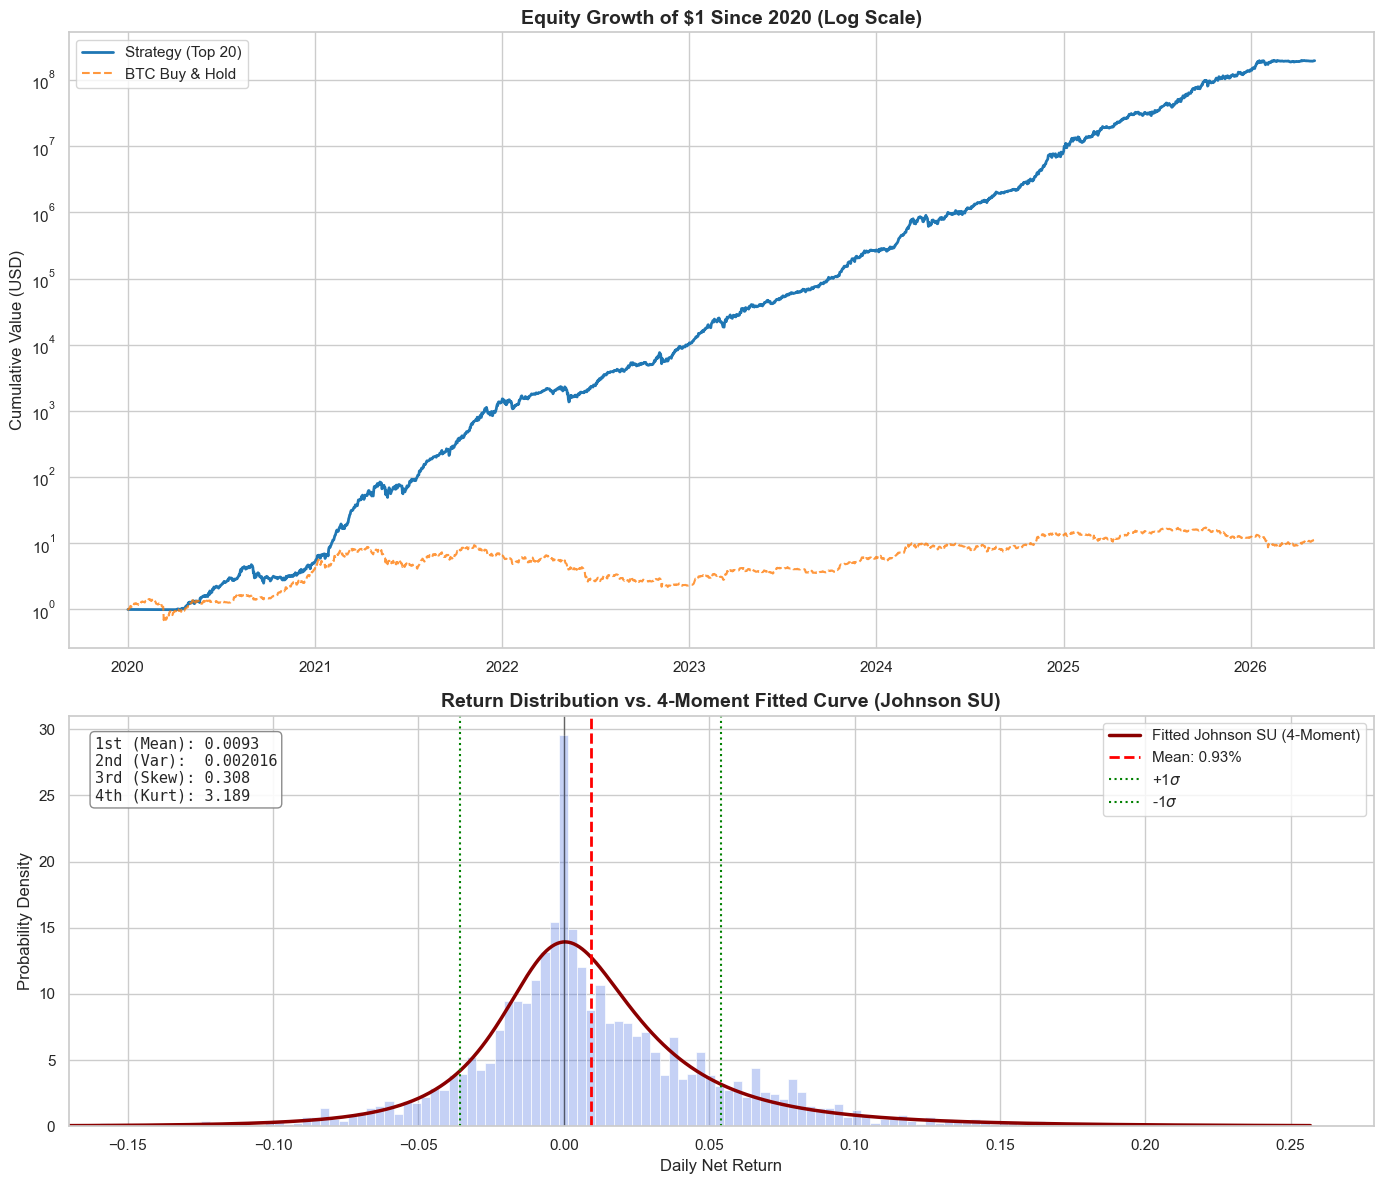

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

# --- 1. Prepare Data ---
dates = strategy_results['ts'].to_numpy()
strat_equity = (strategy_results['net_daily_ret'].fill_null(0) + 1).cum_prod().to_numpy()
btc_equity = (strategy_results['btc_ret_1d'].fill_null(0) + 1).cum_prod().to_numpy()
strat_rets = strategy_results['net_daily_ret'].drop_nulls().to_numpy()

# --- 2. Calculate Statistical Moments ---
mean_ret = np.mean(strat_rets)
std_ret = np.std(strat_rets)
variance = np.var(strat_rets)          # 2nd Moment
skewness = stats.skew(strat_rets)      # 3rd Moment
# We use Fisher’s definition (Excess Kurtosis), where Normal = 0
excess_kurtosis = stats.kurtosis(strat_rets)  # 4th Moment

# --- 3. Fit Johnson SU Distribution (Matches all 4 Moments) ---
# This is the "Gold Standard" for fitting financial return distributions
# a, b are shape parameters (skew/kurtosis), loc is center, scale is width
a_fit, b_fit, loc_fit, scale_fit = stats.johnsonsu.fit(strat_rets)

# --- 4. Plotting ---
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1.5, 1]})

# --- Plot 1: Log Equity Curve ---
ax1.plot(dates, strat_equity, label='Strategy (Top 20)', color='#1f77b4', linewidth=2)
ax1.plot(dates, btc_equity, label='BTC Buy & Hold', color='#ff7f0e', linestyle='--', alpha=0.8)
ax1.set_yscale('log')
ax1.set_title(f'Equity Growth of $1 Since {YEAR} (Log Scale)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cumulative Value (USD)')
ax1.legend(loc='upper left')

# --- Plot 2: Distribution with 4-Moment Fitted Curve ---
# Using more bins to show the "peaky" nature (Kurtosis)
sns.histplot(strat_rets, bins=150, stat='density', color='royalblue', alpha=0.3, ax=ax2)

# Generate fitted Johnson SU PDF
x_axis = np.linspace(strat_rets.min(), strat_rets.max(), 1000)
johnson_pdf = stats.johnsonsu.pdf(x_axis, a_fit, b_fit, loc_fit, scale_fit)
ax2.plot(x_axis, johnson_pdf, color='darkred', linewidth=2.5, label='Fitted Johnson SU (4-Moment)')

# Reference lines
ax2.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax2.axvline(mean_ret, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_ret:.2%}')
ax2.axvline(mean_ret + std_ret, color='green', linestyle=':', linewidth=1.5, label='+1$\sigma$')
ax2.axvline(mean_ret - std_ret, color='green', linestyle=':', linewidth=1.5, label='-1$\sigma$')

# Stats box with all 4 moments
stats_text = (
    f"1st (Mean): {mean_ret:.4f}\n"
    f"2nd (Var):  {variance:.6f}\n"
    f"3rd (Skew): {skewness:.3f}\n"
    f"4th (Kurt): {excess_kurtosis:.3f}"
)
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax2.text(0.02, 0.95, stats_text, transform=ax2.transAxes, fontsize=11, 
         verticalalignment='top', bbox=props, family='monospace')

ax2.set_title('Return Distribution vs. 4-Moment Fitted Curve (Johnson SU)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Daily Net Return')
ax2.set_ylabel('Probability Density')
ax2.legend(loc='upper right')

# Zoom in slightly on the center to see the fit better, while keeping tails visible
ax2.set_xlim(mean_ret - 4*std_ret, mean_ret + 6*std_ret)

plt.tight_layout()
plt.show()

In [336]:
bps_fee = 5
days_holding = 14
num_buckets = 4
days_delta = 7
start_year = 2023

df = (
    pl.read_parquet('polarity/latest-data/*.parquet',missing_columns='insert')
    .sort(['asset','ts'])
    .with_columns(
        fwd=(pl.col('price').shift(-days_holding).over('asset') / pl.col('price') - 1) - (bps_fee / 100.0 / 100.0),
        tcidelta=pl.col('tci') - pl.col('tci').shift(days_delta).over('asset'),

    )
    .filter(
        (pl.col('ts').dt.year() >= start_year) &
        (pl.col('total_volume') >= 1_000_000)
    )
    #.with_columns(**{
    #    c: pl.col(c).qcut(
    #        num_buckets,
    #        labels=[str(i) for i in range(num_buckets)],
    #        allow_duplicates=True
    #    ).over('ts') for c in ['udpil','udpim','udpis','mdccv','mbi','tci','mtm','mcm','tcicv','upprob']
    #})

    # 4.32%
    #.filter(
    #    (pl.col('upprob') > 0.75) &
    #    (pl.col('mdccv') < pl.col('price')) &
    #    (pl.col('tcidelta') > 0)
    #)

    .with_columns(
        ret=pl.when(
            (pl.col('udpim') < pl.col('udpis')) &
            (pl.col('upprob') > 0.75) &
            (pl.col('mdccv') < pl.col('price')) &
            (pl.col('tcidelta') > 0)
        ).then(pl.col('fwd')).otherwise(None)
    )
    .group_by('ts')
    .agg(
        pl.col('fwd').mean(),
        pl.col('ret').mean(),
    )
)

print(f'''
strategy / market
mean: {df.mean()['ret'][0]} / {df.mean()['fwd'][0]}
annualized: {np.pow(df.mean()['ret'][0] + 1, 365/days_holding) - 1} / {np.pow(df.mean()['fwd'][0] + 1, 365/days_holding) - 1}
stdev: {df.std()['ret'][0]} / {df.std()['fwd'][0]}
''')

#df.group_by(pl.col('ts').dt.strftime('%Y-%m')).mean().sort('ts').to_pandas().plot(x='ts',y='fwd',kind='bar')
df.sort('ts').to_pandas().plot(x='ts',y=['ret','fwd'])

TypeError: at least one predicate or constraint must be provided

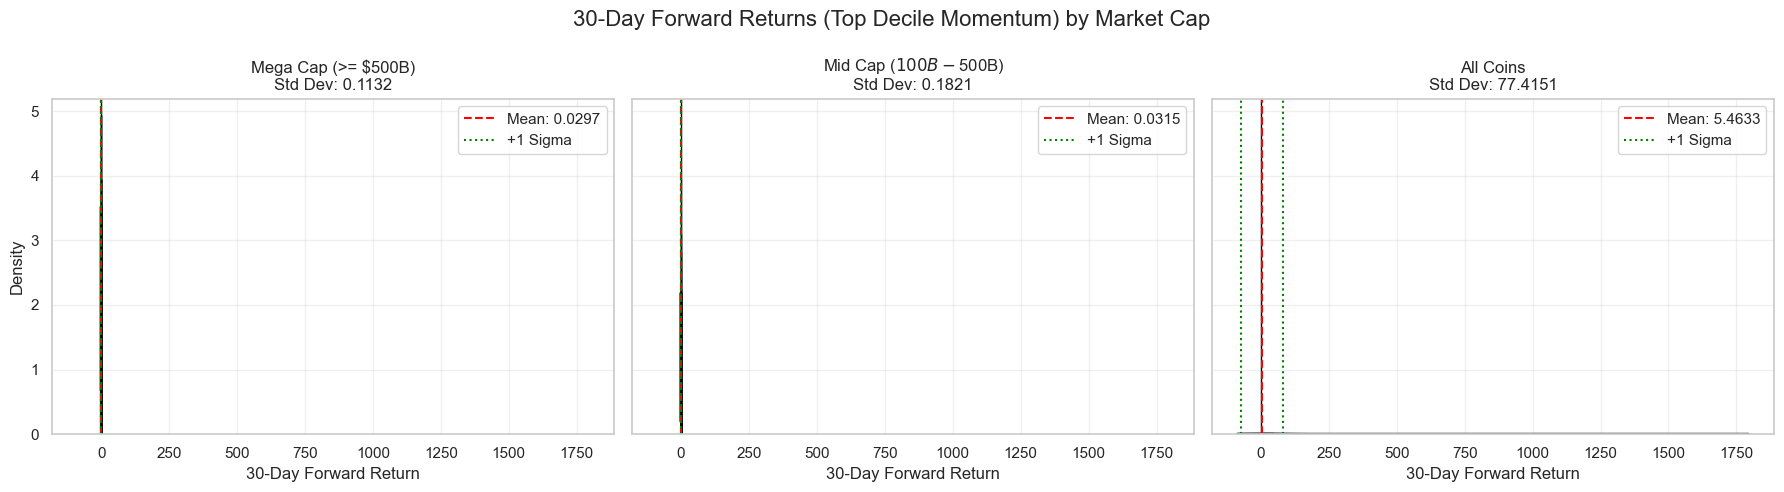

In [335]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# 1. Base Data Pipeline
# Assuming 'mcap' is available in your raw data
df_base = (
    #pl.scan_parquet('polarity/latest-data/*.parquet')
    #.rename({'asset': 'symbol'})
    pl.scan_parquet("cmc-usd-1d-2020-2026.parquet")
    .with_columns(
        price=pl.col('close'),
    )
    .sort(['symbol','ts'])
    .with_columns(
        fwd=pl.col('price').pct_change(-30).over('symbol'),
        mom=pl.col('price').pct_change(90).over('symbol'), # 90-day momentum
    )
    .filter(pl.col('mom').is_not_null() & pl.col('fwd').is_not_null())
    .with_columns(
        rank=pl.col('mom').qcut(
            10,
            labels=[str(i) for i in range(10)],
            allow_duplicates=True
        ).over('ts'),
    )
    .filter((pl.col('rank') == '9') & (pl.col('mom') > 0) & (pl.col('ts').dt.year() >= 2023))
    # We must explicitly select 'mcap' so it is available for filtering below
    .select(['ts', 'symbol', 'market_cap', 'fwd']) 
    .collect()
)

# 2. Define Market Cap Buckets (Assuming mcap is in raw dollars)
# If your data stores mcap in millions, adjust these thresholds (e.g., 10000 instead of 10_000_000_000)
buckets = {
    "Mega Cap (>= $500B)": df_base.filter(pl.col('market_cap') >= 500_000_000_000),
    "Mid Cap ($100B - $500B)": df_base.filter((pl.col('market_cap') >= 100_000_000_000) & (pl.col('market_cap') < 500_000_000_000)),
    "All Coins": df_base
}

# 3. Setup the Subplots
# sharex=True and sharey=True are critical so the visual scale matches across all 3 charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
fig.suptitle('30-Day Forward Returns (Top Decile Momentum) by Market Cap', fontsize=16)

colors = ['forestgreen', 'darkorange', 'steelblue']

# 4. Process and Plot Each Bucket
for ax, (title, subset_df), color in zip(axes, buckets.items(), colors):
    
    # Calculate daily mean returns for this specific mcap bucket
    daily_returns_df = (
        subset_df.group_by('ts')
        .agg(pl.col('fwd').mean())
        .drop_nulls('fwd')
    )
    
    returns = daily_returns_df['fwd'].to_numpy()
    
    # Outlier handling (1st and 99th percentile) to ensure clean bell curves
    if len(returns) > 0:
        lower_bound = np.percentile(returns, 1)
        upper_bound = np.percentile(returns, 99)
        clean_returns = returns[(returns >= lower_bound) & (returns <= upper_bound)]
        
        mu = np.mean(clean_returns)
        sigma = np.std(clean_returns)
        
        # Histogram
        ax.hist(clean_returns, bins=40, density=True, alpha=0.6, color=color, edgecolor='black')
        
        # Bell Curve
        xmin, xmax = ax.get_xlim() # Get axis limits to draw the line
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mu, sigma)
        ax.plot(x, p, 'k', linewidth=2)
        
        # Markings
        ax.axvline(0, color='black', linestyle='-', linewidth=1)
        ax.axvline(mu, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mu:.4f}')
        ax.axvline(mu + sigma, color='green', linestyle=':', linewidth=1.5, label='+1 Sigma')
        ax.axvline(mu - sigma, color='green', linestyle=':', linewidth=1.5)
        
        ax.set_title(f'{title}\nStd Dev: {sigma:.4f}')
        ax.legend()
    else:
        ax.set_title(f'{title}\n(Not Enough Data)')
    
    ax.set_xlabel('30-Day Forward Return')
    ax.grid(True, alpha=0.3)

# Formatting the Y-axis only on the first chart to reduce clutter
axes[0].set_ylabel('Density')
plt.tight_layout()
plt.show()

In [353]:
dtype = pl.Struct([
    pl.Field("days_holding", pl.String),
    pl.Field("top_percentile", pl.String),
    pl.Field("bottom_percentile", pl.String),
    pl.Field("days_momentum", pl.String),
])

(
    pl.read_csv("momentum-research-backtest-results-20260512-134132/*.csv")
    .with_columns(
        pl.col("parameters").str.json_decode(dtype)
    )
    .unnest('parameters')
    .with_columns(
        pl.col('days_holding').cast(pl.Int32),
        pl.col('top_percentile').cast(pl.Float32),
        pl.col('days_momentum').cast(pl.Int32),
    )
    .pivot(on='name', values='data')
    #.select(['sortino','maxdd','cagr','final_equity','signal','gate','interval_days','max_long','max_short'])
    #.filter((pl.col('sortino') > 1) & (pl.col('top_percentile') < 0.99)) 
    .sort('sortino')
    
).write_csv('res.csv')